O objetivo desse problema é investigar como fatores demográficos, sociais e hábitos influenciam nos custos de plano de saúde (Inferência e Modelagem). Além de desenvolver um modelo preditivo para estimar os valores para novos usuários (Machine Learning).
A origem dos dados é o repositorio na plataforma [Kaggle](https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset).

Para isso, temos como variáveis explicativas: age, sex, bmi, children, smoker and region. Enquanto nossa variável alvo é charges.

# 1) EDA

In [76]:
#Importar Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower

#Definir acesso do arquivo
path = "dataset/insurance.csv"

#Criar df
df = pd.read_csv(path)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Columns

age: Age of primary beneficiary (int)

sex: Gender of beneficiary (male, female)

bmi: Body Mass Index, a measure of body fat based on height and weight (float)

children: Number of children covered by health insurance (int)

smoker: Smoking status of the beneficiary (yes, no)

region: Residential region in the US (northeast, northwest, southeast, southwest)

charges: Medical insurance cost billed to the beneficiary (float)



In [77]:
#df criado, vamos entende-lo melhror
print(df.head(5))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [78]:
print(df.describe())
print(df.info())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: floa

Conforme apresentado, não há registros nulo/ausentes. Então vamos analisar a distribuição dos dados e possiveis outliers.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

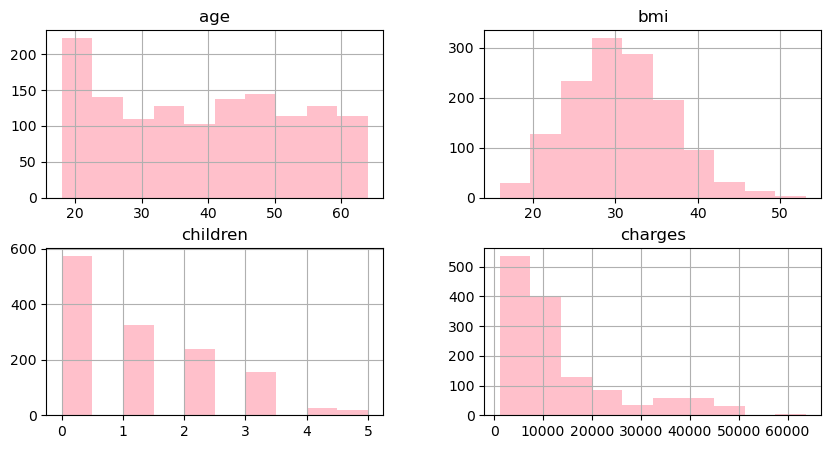

In [79]:
df.hist(bins=10, figsize=(10,5), facecolor = "pink")

Com essa distribuição conclui-se que Charges apresenta uma queda significativa após o valor de 15000, e bmi tem poucos registros <20 e >40. Logo, para melhor visualização, vamos analisar os quartis.

In [80]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<function matplotlib.pyplot.show(close=None, block=None)>

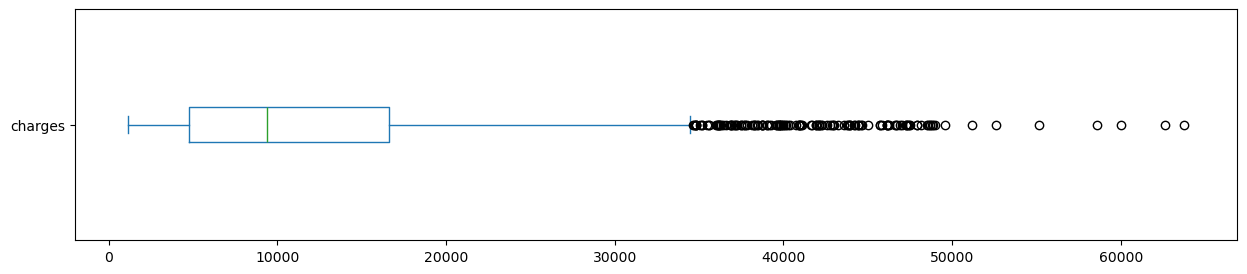

In [81]:
df.charges.plot(kind= "box", vert = False, figsize=(15,3))
plt.show

In [82]:
Q1 = df["charges"].quantile(q = 0.25)
Q3 = df["charges"].quantile(q = 0.75)
DQ = Q3-Q1

LS = round(Q3 + 1.5*DQ, 2)
LI = round(Q1 - 1.5*DQ,2)

print(f"O valor do Limite superior é {LS} enquanto o valor do Limite Inferior é {LI}")
print(f"Existem {len(df[df['charges'] > LS])} registros acima de {LS}")
LS_Charges = LS

O valor do Limite superior é 34489.35 enquanto o valor do Limite Inferior é -13109.15
Existem 139 registros acima de 34489.35


<function matplotlib.pyplot.show(close=None, block=None)>

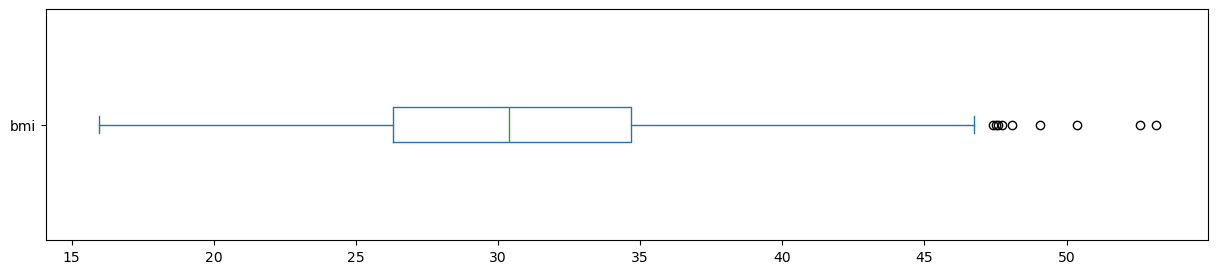

In [83]:
df.bmi.plot(kind= "box", vert = False, figsize=(15,3))
plt.show

In [84]:
Q1 = df["bmi"].quantile(q = 0.25)
Q3 = df["bmi"].quantile(q = 0.75)
DQ = Q3-Q1

LS = round(Q3 + 1.5*DQ, 2)
LI = round(Q1 - 1.5*DQ,2)

print(f"O valor do Limite superior é {LS} enquanto o valor do Limite Inferior é {LI}")
print(f"Existem {len(df[df['bmi'] > LS])} registros acima de {LS}")
LS_bmi = LS

O valor do Limite superior é 47.29 enquanto o valor do Limite Inferior é 13.7
Existem 9 registros acima de 47.29


Vamos entender se há individuos pertencentes aos outliers de Charges e BMI simultaneamente.

In [85]:
df_check = df[ 
    (df['charges'] >= LS_Charges) & 
    (df['bmi'] >= LS_bmi)
]
df_check

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0,yes,southeast,63770.42801
860,37,female,47.60,2,yes,southwest,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820


Agora, é sensato estimar qual o tamanho da amostra para assim entender o valor do poder que diz respeito a probabilidade de rejeitar corretamente H0.

In [86]:
analysis = TTestIndPower()
tamanho_amostra = analysis.solve_power(
    effect_size=0.5, #efeito esperado
    alpha=0.05,
    power=0.8,
    nobs1=None # tamanho ideal da amostra
)
tamanho_amostra = round(tamanho_amostra,0)

print(f"O tamanho ideal da amostra é {tamanho_amostra}")

O tamanho ideal da amostra é 64.0


Logo, para um resultado satisfatorio sendo um efeito de tamanho médio a quantidade que temos de dados é muito maior. Todavia, sabendo que, há cerca 139 possiveis outliers para Charges, cerca de 10% dos dados, enquanto que para bmi há 9 registros, eliminar todos de uma só vez representa uma grande perca do dataset, logo vamos eliminar de inicio somente os que possuem outliers em ambas caracteristicas.

In [87]:
df_clean = df[
    (df["charges"] < LS_Charges) & 
    (df["bmi"] < LS_bmi)
]

df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Para entender melhor as variáveis, vamos analisar as correlações existentes e também verificar se existe alguma multicolenearidade.

## Dataset tratado

In [88]:
# Transformar qualitativas em binárias
df_corr = pd.get_dummies(df_clean, columns=['sex', 'region', 'smoker'], drop_first=True)
df_corr.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'region_northwest',
       'region_southeast', 'region_southwest', 'smoker_yes'],
      dtype='object')

In [89]:
corr = df_corr[[
    'age', 'bmi', 'children', 'charges', 
    'sex_male', 'region_northwest','region_southeast', 
    'region_southwest', 'smoker_yes'
]].corr()

corr

,age,bmi,children,charges,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
age,1.000000,0.122592,0.039967,0.436815,-0.021146,-0.001008,-0.017612,0.016157,-0.067387
bmi,0.122592,1.000000,0.006796,-0.061033,0.016431,-0.112714,0.230967,0.014022,-0.256624
children,0.039967,0.006796,1.000000,0.083093,0.015504,0.012522,-0.015572,0.025880,-0.006034
charges,0.436815,-0.061033,0.083093,1.000000,-0.022511,0.034066,-0.025553,-0.072158,0.602360
sex_male,-0.021146,0.016431,0.015504,-0.022511,1.000000,0.004640,-0.005127,-0.003761,0.014037
region_northwest,-0.001008,-0.112714,0.012522,0.034066,0.004640,1.000000,-0.341199,-0.332879,0.016336
region_southeast,-0.017612,0.230967,-0.015572,-0.025553,-0.005127,-0.341199,1.000000,-0.330680,0.000399
region_southwest,0.016157,0.014022,0.025880,-0.072158,-0.003761,-0.332879,-0.330680,1.000000,-0.046755
smoker_yes,-0.067387,-0.256624,-0.006034,0.602360,0.014037,0.016336,0.000399,-0.046755,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

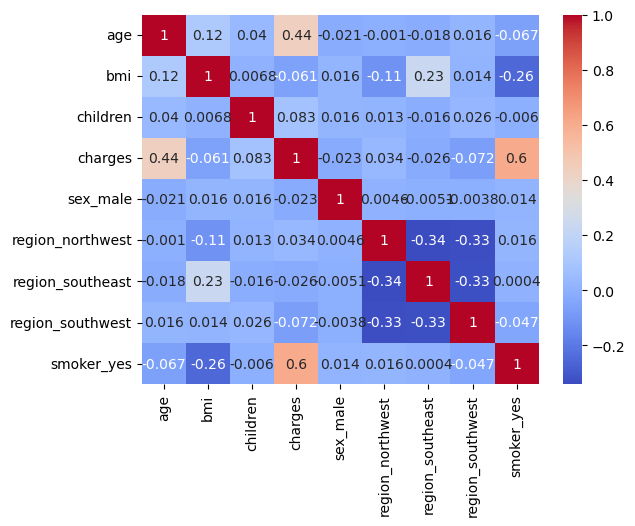

In [90]:
sns.heatmap(
    corr, annot=True, cmap='coolwarm'
)
plt.show

smoker_yes > age > children

O dataset tratado apresenta duas variáveis fortemente explicativas e um possível terceira. Porém para termoz mais certeza, vamos precisar da regressão estatistica.

## Dataset Original

In [91]:
# Transformar qualitativas em binárias
df_corr = pd.get_dummies(df, columns=['sex', 'region', 'smoker'], drop_first=True)
df_corr.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'region_northwest',
       'region_southeast', 'region_southwest', 'smoker_yes'],
      dtype='object')

In [92]:
corr = df_corr[[
    'age', 'bmi', 'children', 'charges', 
    'sex_male', 'region_northwest','region_southeast', 
    'region_southwest', 'smoker_yes'
]].corr()

corr

,age,bmi,children,charges,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
age,1.000000,0.109272,0.042469,0.299008,-0.020856,-0.000407,-0.011642,0.010016,-0.025019
bmi,0.109272,1.000000,0.012759,0.198341,0.046371,-0.135996,0.270025,-0.006205,0.003750
children,0.042469,0.012759,1.000000,0.067998,0.017163,0.024806,-0.023066,0.021914,0.007673
charges,0.299008,0.198341,0.067998,1.000000,0.057292,-0.039905,0.073982,-0.043210,0.787251
sex_male,-0.020856,0.046371,0.017163,0.057292,1.000000,-0.011156,0.017117,-0.004184,0.076185
region_northwest,-0.000407,-0.135996,0.024806,-0.039905,-0.011156,1.000000,-0.346265,-0.320829,-0.036945
region_southeast,-0.011642,0.270025,-0.023066,0.073982,0.017117,-0.346265,1.000000,-0.346265,0.068498
region_southwest,0.010016,-0.006205,0.021914,-0.043210,-0.004184,-0.320829,-0.346265,1.000000,-0.036945
smoker_yes,-0.025019,0.003750,0.007673,0.787251,0.076185,-0.036945,0.068498,-0.036945,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

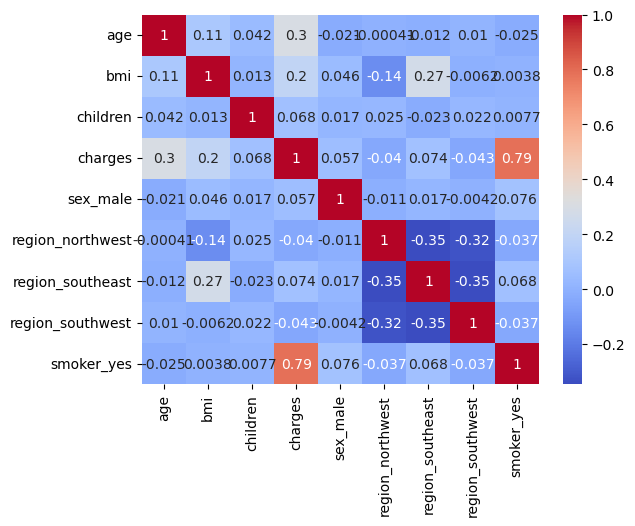

In [93]:
sns.heatmap(
    corr, annot=True, cmap='coolwarm'
)
plt.show

smoker_yes > age > ibm

É comum que, o ato de fumar está diretamente ligado ao custo do seguro de saúde.

Text(0.5, 1.0, 'Custo x Ato de Fumar')

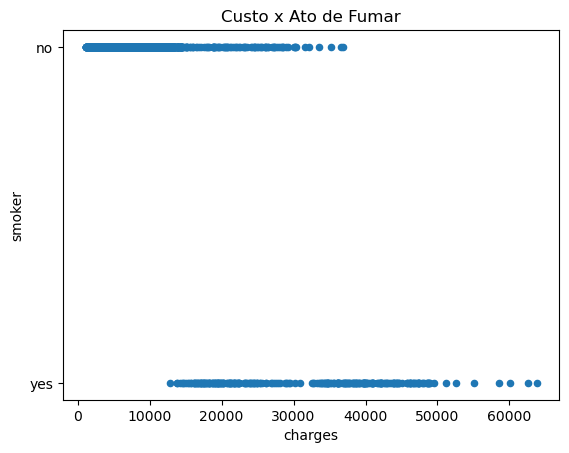

In [95]:
df.plot.scatter("charges", "smoker")
plt.title("Custo x Ato de Fumar")

O dataset original apresenta duas variáveis fortemente explicativas e um possível terceira. Sendo que, a correlação de smoker_yes aumentou 0.19 enquanto age diminiu 0.14. Além disso, para o dataset em questão, bmi é mais significativa que children.

Todavia, importante lembrar que correlação é diferente de causalidade.


### Vamos tirar a conclusão abaixo

In [ ]:
df_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

# 2) Regressão estatistíca

## 2. 1) Dataset tratado

Inicialmente, é feito o carregamento dos dados

In [ ]:
results = smf.ols(
    'charges ~' \
    'age + ' \
    'sex + ' \
    'bmi + ' \
    'children +' \
    'smoker + ' \
    'region',
    data = df_clean
).fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     226.0
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          3.56e-232
Time:                        16:52:47   Log-Likelihood:                -11744.
No. Observations:                1193   AIC:                         2.351e+04
Df Residuals:                    1184   BIC:                         2.355e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -3071.1820    826.381     -3.716      0.000   -4692.516   -1449.848
sex[T.male]          -351.9989    265.317     -1.327      0.185    -872.543     168.545
smoker[T.yes]        1.466e+04    430.007     34.101      0.000    1.38e+04    1.55e+04
region[T.northwest]  -291.6272    373.898     -0.780      0.436   -1025.203     441.949
region[T.southeast] -1045.3948    385.097     -2.715      0.007   -1800.944    -289.846
region[T.southwest] -1330.3238    380.061     -3.500      0.000   -2075.991    -584.656
age                   242.2389      9.525     25.433      0.000     223.552     260.926
bmi                    75.3440     24.349      3.094      0.002      27.572     123.116
children              414.1553    109.164      3.794      0.000     199.978     628.332
==============================================================================
Omnibus:                      744.987   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5164.701
Skew:                           3.001   Prob(JB):                         0.00
Kurtosis:                      11.239   Cond. No.                         325.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretação: 
Coeficiente Intercepto: aumento do valor da variável alvo dado aquela variavel explicativa

p-value: probabilidade de rejeitar a H0

estatistica t: valor que indica a força e significância da variavel explicativa com o alvo 

### Conclusão: 
O modelo apresentou um R² medianamente significativo (0.604). O que indica o que reafirma a possibilidade de as variaveis serem realmente explicativas. Todavia, essa informação ainda é insuficiente.
Logo, partimos para olhar os demais reafirmando o que foi apresentado anteriormente, o ato de fumar está fortemente relacionado ao valor do seguro conforme evidenciado pelo Coeficiente (1.466e+04), pvalue(0.000), e por fim, estatistica t(34.101) com o maior valor dentre todas as variáveis. 
O mesmo acontece para variável age com Coeficiente (242.2389), pvalue(0.000), estatistica t(25.433) e variavel children que dispõe de Coeficiente (414.1553), pvalue(0.000), estatistica t(3.794)


## 2. 2) Dataset original

In [ ]:
results = smf.ols(
    'charges ~' \
    'age + ' \
    'sex + ' \
    'bmi + ' \
    'children +' \
    'smoker + ' \
    'region',
    data = df
).fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:28:10   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    987.819    -12.086      0.000   -1.39e+04      -1e+04
sex[T.male]          -131.3144    332.945     -0.394      0.693    -784.470     521.842
smoker[T.yes]        2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
region[T.northwest]  -352.9639    476.276     -0.741      0.459   -1287.298     581.370
region[T.southeast] -1035.0220    478.692     -2.162      0.031   -1974.097     -95.947
region[T.southwest]  -960.0510    477.933     -2.009      0.045   -1897.636     -22.466
age                   256.8564     11.899     21.587      0.000     233.514     280.199
bmi                   339.1935     28.599     11.860      0.000     283.088     395.298
children              475.5005    137.804      3.451      0.001     205.163     745.838
==============================================================================
Omnibus:                      300.366   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              718.887
Skew:                           1.211   Prob(JB):                    7.86e-157
Kurtosis:                       5.651   Cond. No.                         311.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Conclusão
O modelo apresentou um R²(0.751) maior que torna esse dataset mais competitivo.
Conforme previamente calculado pela correlação, o ato de fumar é o maior relacionado ao custo do valor do seguro de saúde, visto que apresenta maior coeficiente (2.385e+04), um p value minimo(0.000) e a maior estatistica t(57.723). Lembrando que pela correlação temos que age > bmi > children, com o calculo da regressão entedemos que bmi tem valor maior de explicação dado que seu coeficiente é maior ainda que o intervalo de variação seja menor. Explicando melhor: 
Age[18-64] ⮕ Δ = 46 ⮕ β = 256.8564 ⮕ Var = 11815.39
bmi[15.96 - 53.13] ⮕ Δ = 37.17 ⮕ β = 339.1935 ⮕ Var = 12607.82
